# Univariate Analysis 

**Types of Data:** :
 - **Numerical** → Continuous (e.g., `Age: 24.5`) / Discrete (e.g., `Number of siblings: 2`)
 - **Categorical** → Nominal (no order, e.g., `Gender: Male/Female`) / Ordinal (has order, e.g., `Rating: Poor < Average < Good < Excellent`)

**Definition :** Analysis of a single variable (column) to understand its distribution, frequency, and basic characteristics.
  - 1 variable → Uni(one)variate(variable) Analysis
  - We explore variables one by one or Independent analysis of each variable
  - Method to perform uni-variate analysis will depend on whether the variable type is categorical or continuous.


- **Continuous/Numerical Variable Analysis** :

  - Measure of central tendency(Mean, Median, Mode) of the variable.
  - Measure of spread(Range,IQR, Variance,Standard Deviation) of the variable.
  - Measure of Shape(Symmetrical Distribution e.g. Normal Distribution,Asymmetrical Distribution (Left or Right Skewed Distribution),Kurtosis(shape of the of the distribution in terms of height or flatness)
  - Graphs:
    - Histogram → Distribution / frequency across ranges → `sns.histplot(data=df, x='Age', bins=20, kde=False)`
    - KDE Plot → Smooth distribution / shape → `sns.kdeplot(data=df, x='Age', fill=True, bw_adjust=1)`
    - Boxplot → Median, quartiles, spread, and outliers → `sns.boxplot(data=df, x='Age')`
    - ECDF Plot → Cumulative proportion of observations → `sns.ecdfplot(data=df, x='Age')`
    - Distplot → Distribution plot (**deprecated in Seaborn**) → `sns.distplot(df['Age'])` → use `sns.histplot(data=df, x='Age', kde=True)` instead

- **Categorical Variable Analysis** :

  - For categorical variables, we will use frequency distribution of each category.e.g Bar Chart, Pie Chart
  - Graphs :
     - Countplot / Bar Chart (Frequency Count) → Frequency / count of each category → `sns.countplot(data=df, x='Sex', order=df['Sex'].value_counts().index)`
     - Pie Chart (Percentage Count)→ Proportion / percentage of each category → `df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)`

<br><br>
<img src="../../images/Univariate.png" width="1000">
    


#### 1) Load DataSet

What question(s) are we trying to solve?

predicts which passengers survived in the Titanic shipwreck.

Dataset is Titanic Datset. > https://www.kaggle.com/c/titanic/data

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(style="darkgrid")# "whitegrid")
%matplotlib inline 
# use this command so that your plots appear inline in your notebook

In [49]:
# load the dataset
df = pd.read_csv("../../dataset/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [51]:
# index change - Use PassengerId as Index
df = df.set_index("PassengerId")
df.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### 2) Variable Identification

- Identify Variable data types. Variable important for target variables
- identify & Segregate them into numaerical/categorical
- identify unimportnat classes

Categorical - Survived(target/binary), PClass, Gender
Numrical - 

## **Univariate Analysis**

### **1) Categorical Data**

#### **1.1.BarChart /Countplot** - Frequency Count

In [52]:
# Lets Analysis the Target Variable "Survived"
# Calculate the percentage of people who Survived and Not Survived
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

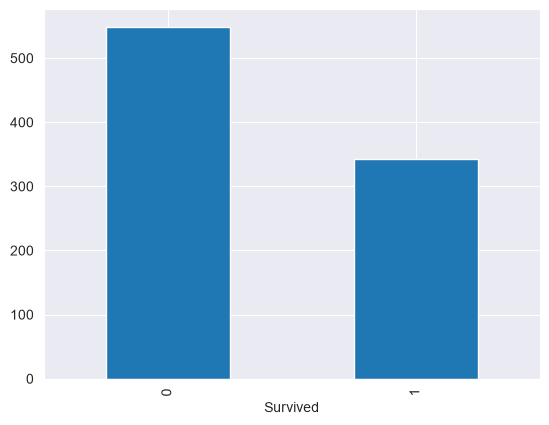

In [53]:
# barchart - matplotlib
df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Survived', ylabel='count'>

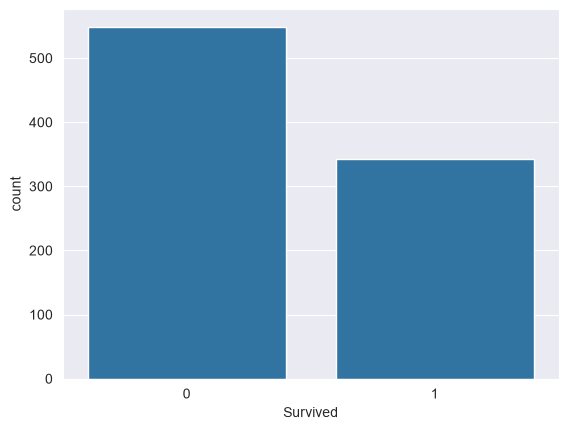

In [ ]:
# Seaborn
# A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable.
# wrong does not work :
# sns.countplot(df['Survived']) 
# correct :
# sns.countplot(x=df['Survived'])
# sns.countplot(x=df['Survived'], hue=df['Survived'])
# most preferred way 
sns.countplot(data=df,x="Survived") 

<Axes: xlabel='Survived', ylabel='count'>

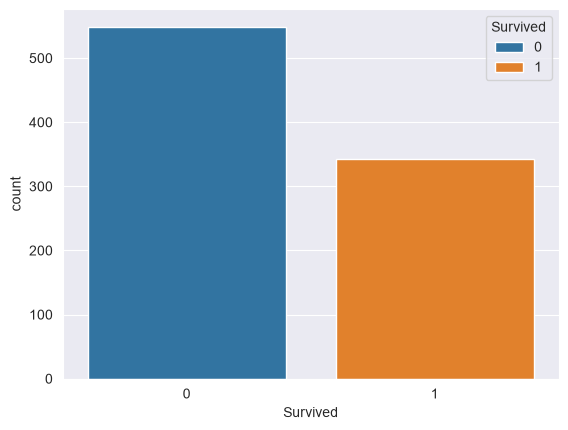

In [55]:
sns.countplot(data=df, x='Survived', hue='Survived')

**hue** :

- hue = groups the data by another variable and gives each group a different color.
- Ex : hue='Sex'
- Think of hue as: “Use another column to split/color the data into groups.”
- Ex: Bivariate Analysis (Survived and Sex)
   - With hue='Sex', each Survived category is further divided into:
   - Survived = 0 → Male + Female
   - Survived = 1 → Male + Female

   - So hue lets us see the relationship between the main variable and another categorical variable using different colors.

- x    → Main variable
- hue  → Variable used to split/group the main variable

<Axes: xlabel='Survived', ylabel='count'>

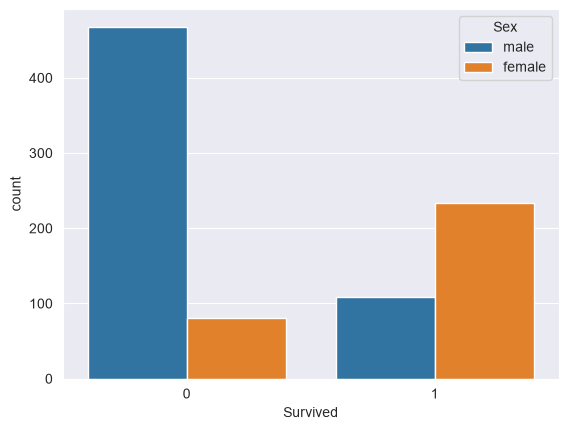

In [ ]:
# Bivariate Analysis - 2 variables - survived & sex
sns.countplot(data=df, x='Survived', hue='Sex')

C:\Users\HP\AppData\Local\Temp\ipykernel_25480\1959616746.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  graph.set_xticklabels(graph.get_xticklabels(),rotation=90)


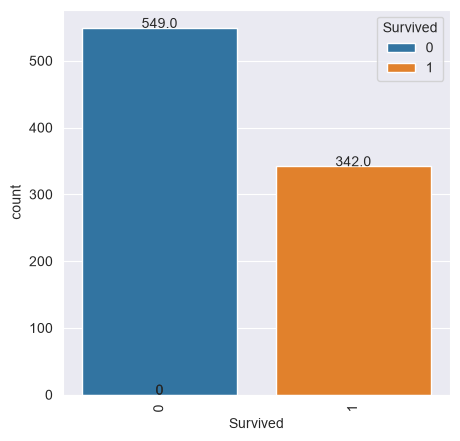

In [57]:
# Lets Display Count on top of countplot
fig, ax1 = plt.subplots(figsize=(5,5))
graph = sns.countplot(ax=ax1,x='Survived', data=df, hue='Survived')
graph.set_xticklabels(graph.get_xticklabels(),rotation=90)
for p in graph.patches:
    height = p.get_height()
    graph.text(p.get_x()+p.get_width()/2., height + 0.1,height ,ha="center")

<Axes: xlabel='Pclass', ylabel='count'>

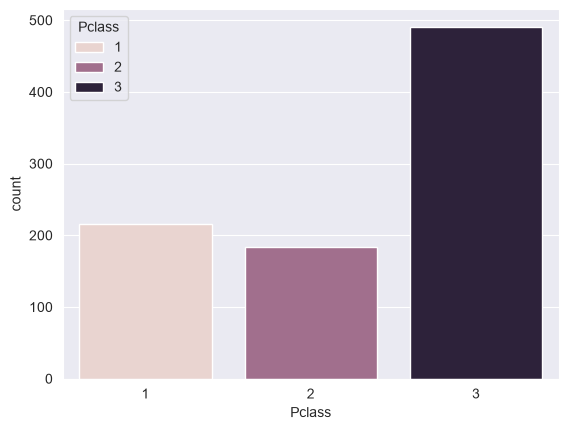

In [62]:
# sns.countplot(data=df,x='Sex')
# sns.countplot(data=df,x='Pclass')
sns.countplot(data=df,x='Pclass', hue='Pclass')

#### **1.2.Piechart** - Percentage Count

In [58]:
per_sur_nonsur = (df["Survived"].value_counts()/df.shape[0]*100).round(2)
per_sur_nonsur
# 0 > not-Survived
# 1 > Survived

Survived
0    61.62
1    38.38
Name: count, dtype: float64

<Axes: >

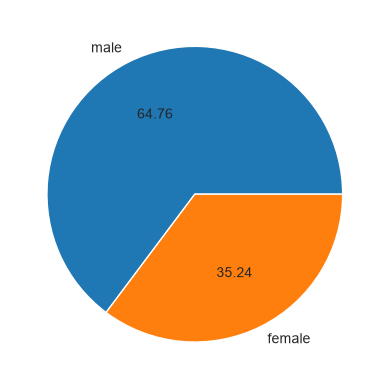

In [59]:
# pie chart - matplotlib
# df['Survived'].value_counts().plot(kind="pie", autopct='%.2f')
df['Sex'].value_counts().plot(kind="pie", autopct='%.2f')
# df['Pclass'].value_counts().plot(kind="pie", autopct='%.2f')

- Matplotlib - bar, pie
- Seaborn - CountPlot

### **2) Numerical Data**

#### **describe()** 

In [63]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### What to look for in describe()

- `count` → Compare with total rows to identify missing values and how many need to be handled before analysis/modeling
   - count = total rows → No missing values in that column.
   - count < total rows → Missing values are present.
   - Larger difference → More missing values need to be handled before analysis/modeling.
- `Mean` → average value around which the data is centered.  it is calculated using every value and can be affected by extreme values
   - Gives a general idea of where the data is centered.
   - Compare mean with 50% (median) to get a quick hint about possible skewness.
   - **Mean can be pulled toward extreme values.**
- `mean vs 50% (median)` → Compare them to get a quick hint about **possible skewness**. Large difference may indicate skewness

    **Mean**
    - `Mean` → The **arithmetic average** of all values; it represents the average/center of the data.
    - Mean is **sensitive to extreme values** because every value contributes to the calculation.

    **Median**
    - `Median` → The **middle value** when the data is arranged in ascending order.
    - Median is **less affected by extreme values** compared with the mean.

    **Mode**
    - `Mode` → The **most frequently occurring value** in the data.
    - Mode represents the value around which the data has the **highest frequency**.

    **Using Mean, Median and Mode for Skewness**
    - **Symmetric** → `Mean ≈ Median ≈ Mode`
      - Ex : Heights =  `160, 165, 168, 170, 171, 172, 174, 177, 180`. Values are **roughly balanced on both sides** . Indicates Symmetric Curve / Normal Distribution
    - **Right / Positive skew** → `Mode < Median < Mean` 
      - long tail toward the **right**; high values pull the mean upward.
      - Ex : Salary : `20K, 22K, 25K, 28K, 30K, 35K, 40K, 200K`. Most values are lower, few **very high values** → long **right tail →** → Right / Positive skew and `Mean > Median` and unsymmetric curve
    - **Left / Negative skew** → `Mean < Median < Mode`   
      - long tail toward the **left**; low values pull the mean downward.
      -  Ex: marks = `20, 65, 75, 80, 82, 85, 88, 90, 95`. Most values are higher, few **very low values** → long **left tail ←** → Left / Negative skew and Mean < Median and unsymmetric curve

   - <img src="../../images/skewness(mean-mode-median).png" width="800">
    - `Mean > Median` → Possible **right/positive skew** → **extreme high values pull the mean toward the right (upward)**. Since only a **small number of observations have very high values**, these values extend farther toward the right, creating a **long right tail →**, hence the name **right/positive skew**.
    - `Mean < Median` → Possible **left/negative skew** → **extreme low values pull the mean toward the left (downward)**. Since only a **small number of observations have very low values**, these values extend farther toward the left, creating a **long left tail ←**, hence the name **left/negative skew**.
    - `Mean ≈ Median` → No strong skew indicated → Values are distributed more **symmetrically** around the center, so there is no long tail clearly extending toward either side.

    **Histogram - Data Distribution - Skewness** :
    - A **histogram** is used to understand how the values of **one numerical column are distributed**.It does this by:
       - Steps :
          ```text
          1. Taking all the values in the column.
          2. Dividing the value range into **bins** (intervals/ranges).
          3. Counting how many observations fall into each bin. Bins are ranges and are sorted 
          4. Representing those counts using bars.
          ```
       - Therefore:
         - **X-axis** → Fare ranges (**bins**)
         - **Y-axis** → Number of observations (**count/frequency**)
         - **Bar height** → How many observations are in that range
       - For example,    `df["Fare"].hist()`
         - Suppose the data is:Fare values → 10, 20, 25, 30, 35, 40, 45, 60, 120, 150
         The observations are grouped into bins: `0–50` → **7 observations** ; `50–100` → **1 observation** ;  `100–150` → **1 observation** ; `150–200` → **1 observation**
         - Therefore, the `0–50` bar will be the **tallest**, because most observations fall in that range.
         - <img src="../../images/skewness(mean vs median).png" width="800">

       - The histogram helps us visually identify:
          - Where most values are concentrated
          - How spread out the values are
          - Whether the distribution is **symmetric or skewed**
          - Whether there are unusually extreme values

      - **Example of right skewness:**
          - If most passengers have Fare values between **0–50**, but only a few passengers have very high fares like **300–500**, the bars will be concentrated on the left and a few smaller bars will extend toward the right.
          - These few high values create a **long right tail →**, indicating a **right/positive skewed distribution**.

      - **Important:** The histogram does not create skewness. It **shows the distribution**, allowing us to visually observe skewness.

    - Histogram reasoning for skewness :
      - **Right / Positive skew** → Many observations are concentrated at **lower-medium values**, while a **small number of very high values** extend farther toward the right.
         - Histogram → More/taller bars toward the lower values + fewer/shorter bars continuing toward higher values.
         - These few high values create the **long right tail →**.
         - The high values pull the **mean toward the right/upward**.
         - Therefore → `Mean > Median` → **Right / Positive skew**.

      - **Left / Negative skew** → Many observations are concentrated at **higher values**, while a **small number of very low values** extend farther toward the left.
         - Histogram → More/taller bars toward the higher values + fewer/shorter bars continuing toward lower values.
         - These few low values create the **long left tail ←**.
         - The low values pull the **mean toward the left/downward**.
         - Therefore → `Mean < Median` → **Left / Negative skew**.

    - The side where the few extreme values stretch out is the side where the tail is — and that is what determines the name of the skew.
       - So few high values → right tail → right/positive skew.
       - Few low values → left tail → left/negative skew.

    - **Skewness ≠ Outliers**
       - **Skewness** → describes the **overall shape/asymmetry** of the distribution.
       - **Outlier** → an **individual value** that is unusually far from the rest.
       - For example, if most fares are ₹10–₹50 but a few fares are ₹300–₹500:
          - Those ₹300–₹500 values may be **outliers**.
          - They extend the distribution toward the **right**, creating a **right-skewed distribution**.
          - They also pull the **mean upward**.
       - So,  **Outliers can cause skewness, but a skewed distribution does not necessarily mean it contains outliers.**

    - **Mean / Median / Skewness for categorical columns** → Generally **not meaningful** for ordinary categorical data.
       - **Types of Data:**
         - **Numerical** → Continuous (e.g., `Age: 24.5`) / Discrete (e.g., `Number of siblings: 2`)
         - **Categorical** → Nominal (no order, e.g., `Gender: Male/Female`) / Ordinal (has order, e.g., `Rating: Poor < Average < Good < Excellent`)
       - Some categorical columns may be represented using numbers, such as `Sex: 0/1` or `Pclass: 1/2/3`.
       - Even though they contain numbers, the numbers may represent **categories rather than continuous numerical values**.
       - Therefore, mean, median and skewness should **not automatically be interpreted like normal numerical data**.
       - For categorical columns, focus more on **value counts, frequency and proportions**.

- `min/max` → Look for extreme or unusual values / possible outliers.
  - `min` → The **smallest observed value** in the column.Very small/unusual values → Possible extreme values or data issues. Compare it with 25% (Q1) to see how far the lower extreme is from the main data.
  - `max` → The **largest observed value** in the column.Very large/unusual values → Possible extreme values or data issues. Compare it with 75% (Q3) to see how far the upper extreme is from the main data
  - `max - min` → Shows the **overall range** of the observed values, but it can be strongly affected by extreme values. - `max - min` → Shows the **range** of the data; a very small range **may indicate** a categorical/discrete column, but it does not necessarily mean the column is categorical.
  - Compare `min/max` with `25%` and `75%` to see whether values are unusually far from the main data.
  - Min/max alone **cannot prove** that a value is an outlier; use methods such as **IQR or box plot** later.
  
- `std` → Understand how spread out the values are around the mean. This number comes from looking at **every value's distance from the mean**.

  - Larger `std` → Values generally have **more variation** around the mean. Values have relatively high variation/spread
  - Smaller `std` → Values are generally **more concentrated** around the mean.
  - Compare std with the mean to understand whether the variation is small or large relative to the average.
  - `std` measures **spread**, not whether values are outliers.

- `25% and 75%` → Understand where the **middle 50% of data lies**.

  - `25% (Q1)` → 25% of the values are **at or below** this value.
  - `50% (Median)` → 50% of the values are **at or below** this value. Less affected by extreme values than the mean.Compare with mean to get a quick hint about possible skewness.
  - `75% (Q3)` → 75% of the values are **at or below** this value.
  - Therefore, `Q1 → Q3` contains the **middle 50% of the data**.
  - Q3 - Q1 → IQR, which measures the spread of the middle 50%.
  - Larger IQR → Middle 50% is more spread out.
  - Smaller IQR → Middle 50% is more concentrated.

- `min → 25% → 50% → 75% → max` → Get a quick idea of **how the values are distributed**.

  - Look at the **spacing between these points**.
  - Similar spacing → Values may be distributed relatively evenly.
  - Unequal spacing → May indicate **skewness, concentration, or extreme values**.
  - This gives a quick distribution overview before using plots such as a **histogram or box plot**.

- Missingness → Center → Skew → Range → Spread → Quartiles → Distribution → Possible outliers

In [64]:
df['Age'].mean()

np.float64(29.69911764705882)

#### **2.1.Histogram** 

- Understand the distribution of data in the numerical Column. A histogram shows how numerical values are distributed by dividing the values into bins and counting how many observations fall into each bin

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

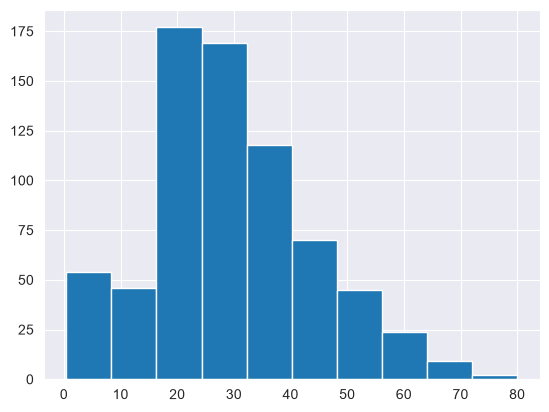

In [66]:
# matplotlib
plt.hist(df['Age'])

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

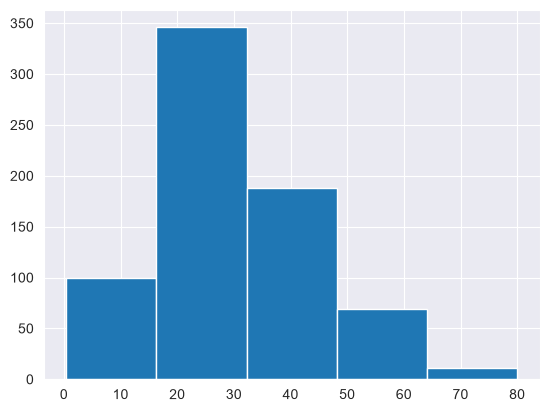

In [68]:
plt.hist(df['Age'], bins=5)

<Axes: xlabel='Age', ylabel='Count'>

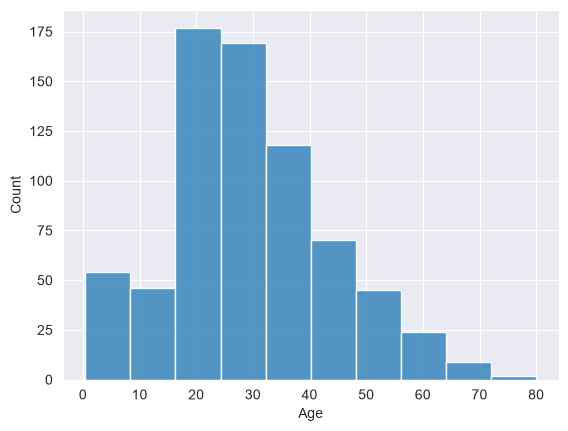

In [74]:
# seaborn 
sns.histplot(data=df, x="Age", bins=10)
# sns.histplot(data=df, x="Age", bins=10, hue='Sex')

#### **2.2.DistPlot** 

- distplot() was basically a distribution plot that could show a histogram + KDE curve
- Histogram → bars showing the frequency/count of values
- KDE → Kernel Density Estimation . KDE = a smooth estimate of the data's distribution. KDE takes your actual data points and creates a smooth curve representing the estimated distribution of the data.
- distplot() is deprecated. Don't use it for new code.either use KDEplot or Histplot with KDE

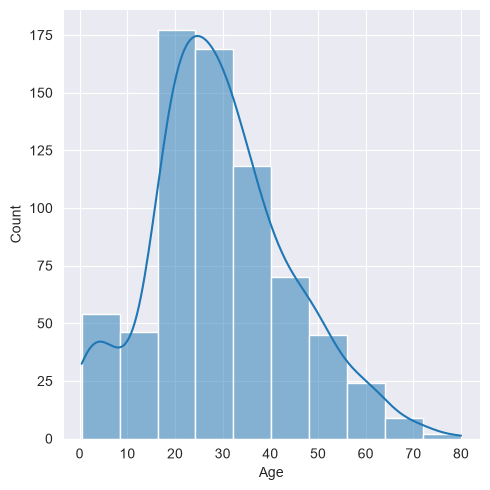

In [ ]:
sns.displot(data=df,x='Age', bins=10, kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

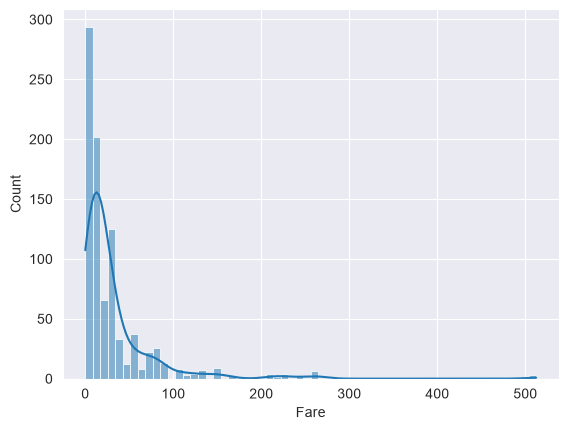

In [ ]:
sns.histplot(data=df, x="Fare", kde=True)
# seems positive/right skewed

#### **2.3.KDE plot** 

<Axes: xlabel='Age', ylabel='Density'>

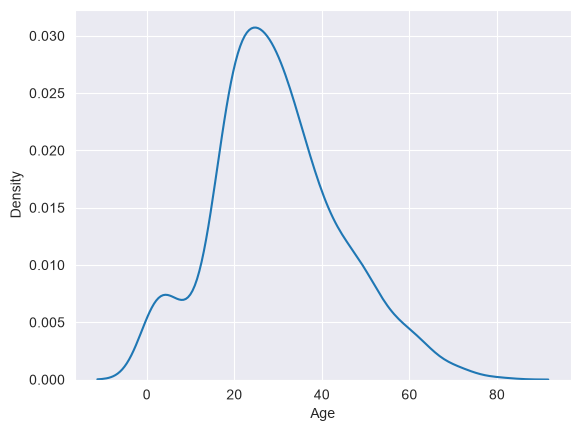

In [80]:
sns.kdeplot(data=df, x='Age')

#### **2.4. Box Plot - Outlier Identification**

- Gives 5-number summary
- IQR = Inter Quartile Range = Q3 - Q1
- Lower Bound = Q1 - 1.5 * IQR
- Upper Bound = Q3 + 1.5 * IQR
- Lower Bound and Upper Bound are not the actual minimum and maximum values of the data; they are the limits used to identify potential outliers.
- The actual minimum and maximum non-outlier values are the ends of the whiskers, while data points beyond these bounds are considered potential outliers.

<img src="../../images/boxplot-outliers.png" width="800">

<Axes: xlabel='Fare'>

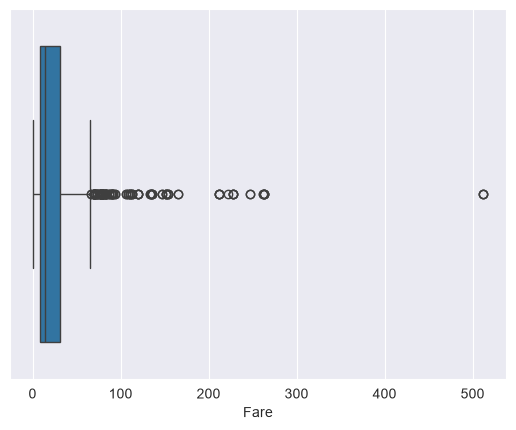

In [84]:
# sns.boxplot(df['Fare'])
sns.boxplot(data=df,x='Fare')

<Axes: xlabel='Age'>

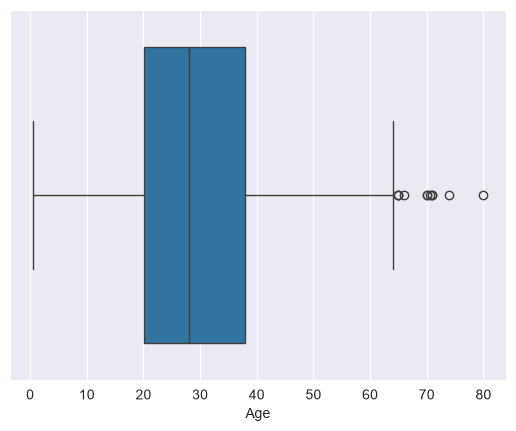

In [85]:
sns.boxplot(data=df,x='Age')

#### **2.4. ECDF Plot**

<Axes: xlabel='Age', ylabel='Proportion'>

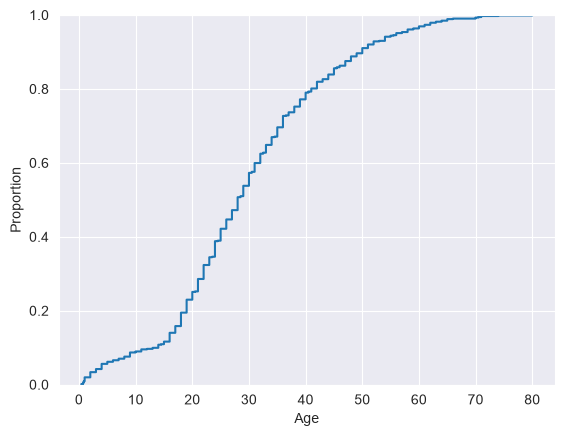

In [81]:
sns.ecdfplot(data=df, x='Age')

Please refer for more detailed analysis : https://github.com/atulpatelDS/Youtube/blob/main/EDA/Univariate%20Analysis%20vs%20Bivariate%20Analysis%20vs%20Multivariate%20Analysis.ipynb